# Model Evaluation Demo - Portuguese Bank Marketing Dataset

This notebook demonstrates comprehensive model evaluation utilities using the **Portuguese Bank Marketing Dataset**. We'll showcase:

1. **ModelMetrics**: Comprehensive metrics container
2. **ModelEvaluator**: Advanced evaluation and visualization tools
3. **Model Comparison**: Comparing multiple models side-by-side
4. **Evaluation Reports**: Generating comprehensive evaluation reports

## Dataset Overview
- **Problem Type**: Bank marketing campaign success prediction
- **Target**: Whether client subscribed to term deposit (binary classification)
- **Features**: Client demographics, campaign details, economic indicators
- **Size**: ~4,500 samples with 20 features

## Setup and Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from fair_credit.models.metrics import ModelMetrics, ModelEvaluator
from fair_credit.models import LogisticRegressionModel, XGBoostModel

np.random.seed(42)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Load and Explore Portuguese Bank Dataset

Let's load the Portuguese bank marketing dataset and explore its structure.

In [15]:
print('Loading Portuguese Bank Marketing Dataset...')
print('=' * 60)

try:
    df = pd.read_csv('../data/Portugese_bank.csv', sep=';')
    
    print(f"Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"\nColumns ({len(df.columns)}): {df.columns.tolist()}")

    print(f"\nFirst 5 rows:")
    display(df.head())
    
    print(f"\nDataset Information:")
    print(f"- Total samples: {len(df):,}")
    print(f"- Features: {len(df.columns) - 1}")
    print(f"- Missing values: {df.isnull().sum().sum()}")
    
    if 'y' in df.columns:
        print(f"\nTarget Variable Analysis ('y' - Term Deposit Subscription):")
        target_counts = df['y'].value_counts()
        target_pct = df['y'].value_counts(normalize=True)
        
        print(f"Target values: {df['y'].unique()}")
        print(f"\nTarget distribution:")
        for value in target_counts.index:
            print(f"  {value}: {target_counts[value]:,} ({target_pct[value]:.1%})")

        success_rate = (df['y'] == 'yes').mean()
        print(f"\nCampaign Success Rate: {success_rate:.2%}")
        if success_rate < 0.2:
            print("Highly imbalanced dataset - success rate < 20%")
        elif success_rate < 0.3:
            print("Moderately imbalanced dataset - success rate < 30%")
        else:
            print("Reasonably balanced dataset")
    
    print(f"\nData Types:")
    print(df.dtypes)
    
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"\nFeature Types:")
    print(f"- Categorical features ({len(categorical_cols)}): {categorical_cols}")
    print(f"- Numerical features ({len(numerical_cols)}): {numerical_cols}")
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure 'Portugese_bank.csv' exists in the parent directory")

Loading Portuguese Bank Marketing Dataset...
Dataset loaded successfully!
Dataset shape: (4521, 17)

Columns (17): ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no



Dataset Information:
- Total samples: 4,521
- Features: 16
- Missing values: 0

Target Variable Analysis ('y' - Term Deposit Subscription):
Target values: ['no' 'yes']

Target distribution:
  no: 4,000 (88.5%)
  yes: 521 (11.5%)

Campaign Success Rate: 11.52%
Highly imbalanced dataset - success rate < 20%

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Feature Types:
- Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
- Numerical features (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## 2. Data Preprocessing and Feature Engineering

Let's clean the data and prepare features for machine learning models.

In [29]:
print('DATA PREPROCESSING AND FEATURE ENGINEERING')
print('=' * 60)

if 'df' in locals() and not df.empty:
    data = df.copy()
    
    print("\n1. Handling missing values...")
    missing_before = data.isnull().sum().sum()
    print(f"   Missing values before: {missing_before}")
    
    if missing_before > 0:
        for col in data.columns:
            if data[col].dtype == 'object':
                data[col] = data[col].fillna('unknown')
            else:
                data[col] = data[col].fillna(data[col].median())
    
    missing_after = data.isnull().sum().sum()
    print(f"   Missing values after: {missing_after}")
    
    print("\n2. Processing target variable...")
    if 'y' in data.columns:
        target_mapping = {'no': 0, 'yes': 1}
        data['target'] = data['y'].map(target_mapping)
        
        print(f"   Target mapping: {target_mapping}")
        print(f"   Success rate: {data['target'].mean():.2%}")
        
        target_column = 'target'
    else:
        print("No target column 'y' found")
        target_column = None
    
    print("\n3. Feature preparation...")
    if target_column:
        feature_columns = [col for col in data.columns if col not in ['y', 'target']]
        X = data[feature_columns].copy()
        y = data[target_column].copy()
        
        print(f"   Features ({len(feature_columns)}): {feature_columns}")
        print(f"   Target: {target_column}")
        
        categorical_columns = X.select_dtypes(include=['object']).columns
        print(f"\n   Encoding categorical variables ({len(categorical_columns)}):")
        
        label_encoders = {}
        for col in categorical_columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
            print(f"     {col}: {len(le.classes_)} unique values")
        
        print("\n4. Splitting data...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, 
            test_size=0.3, 
            random_state=42, 
            stratify=y
        )
        
        print(f"   Training set: {X_train.shape[0]:,} samples")
        print(f"   Test set: {X_test.shape[0]:,} samples")
        print(f"   Training success rate: {y_train.mean():.2%}")
        print(f"   Test success rate: {y_test.mean():.2%}")
        
        print(f" Feature Statistics (Training Set):")
        display(X_train.describe())
        
        print("\nData preprocessing complete!")
        
    else:
        print("Cannot proceed without target variable")
        
else:
    print("No dataset available for preprocessing")

DATA PREPROCESSING AND FEATURE ENGINEERING

1. Handling missing values...
   Missing values before: 0
   Missing values after: 0

2. Processing target variable...
   Target mapping: {'no': 0, 'yes': 1}
   Success rate: 11.52%

3. Feature preparation...
   Features (16): ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
   Target: target

   Encoding categorical variables (9):
     job: 12 unique values
     marital: 3 unique values
     education: 4 unique values
     default: 2 unique values
     housing: 2 unique values
     loan: 2 unique values
     contact: 3 unique values
     month: 12 unique values
     poutcome: 4 unique values

4. Splitting data...
   Training set: 3,164 samples
   Test set: 1,357 samples
   Training success rate: 11.54%
   Test success rate: 11.50%
 Feature Statistics (Training Set):


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
count,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000
mean,41.054678,4.419090,1.142225,1.229456,0.018647,1406.905499,0.567636,0.155499,0.645070,16.050885,5.576485,265.302149,2.798357,39.932364,0.515803,2.551517
std,10.386760,3.277853,0.605591,0.752573,0.135297,2810.333965,0.495483,0.362437,0.899716,8.222576,2.986347,263.214008,3.128472,100.104153,1.490216,0.997405
min,19.000000,0.000000,0.000000,0.000000,0.000000,-3313.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,1.000000,1.000000,1.000000,0.000000,64.000000,0.000000,0.000000,0.000000,9.000000,3.000000,104.000000,1.000000,-1.000000,0.000000,3.000000
50%,39.000000,4.000000,1.000000,1.000000,0.000000,452.000000,1.000000,0.000000,0.000000,16.000000,6.000000,185.000000,2.000000,-1.000000,0.000000,3.000000
75%,48.000000,7.000000,2.000000,2.000000,0.000000,1490.000000,1.000000,0.000000,2.000000,21.000000,8.000000,332.000000,3.000000,-1.000000,0.000000,3.000000
max,87.000000,11.000000,2.000000,3.000000,1.000000,42045.000000,1.000000,1.000000,2.000000,31.000000,11.000000,3025.000000,50.000000,871.000000,22.000000,3.000000



Data preprocessing complete!


## 3. Exploratory Data Analysis

Let's explore the dataset characteristics and relationships.

EXPLORATORY DATA ANALYSIS


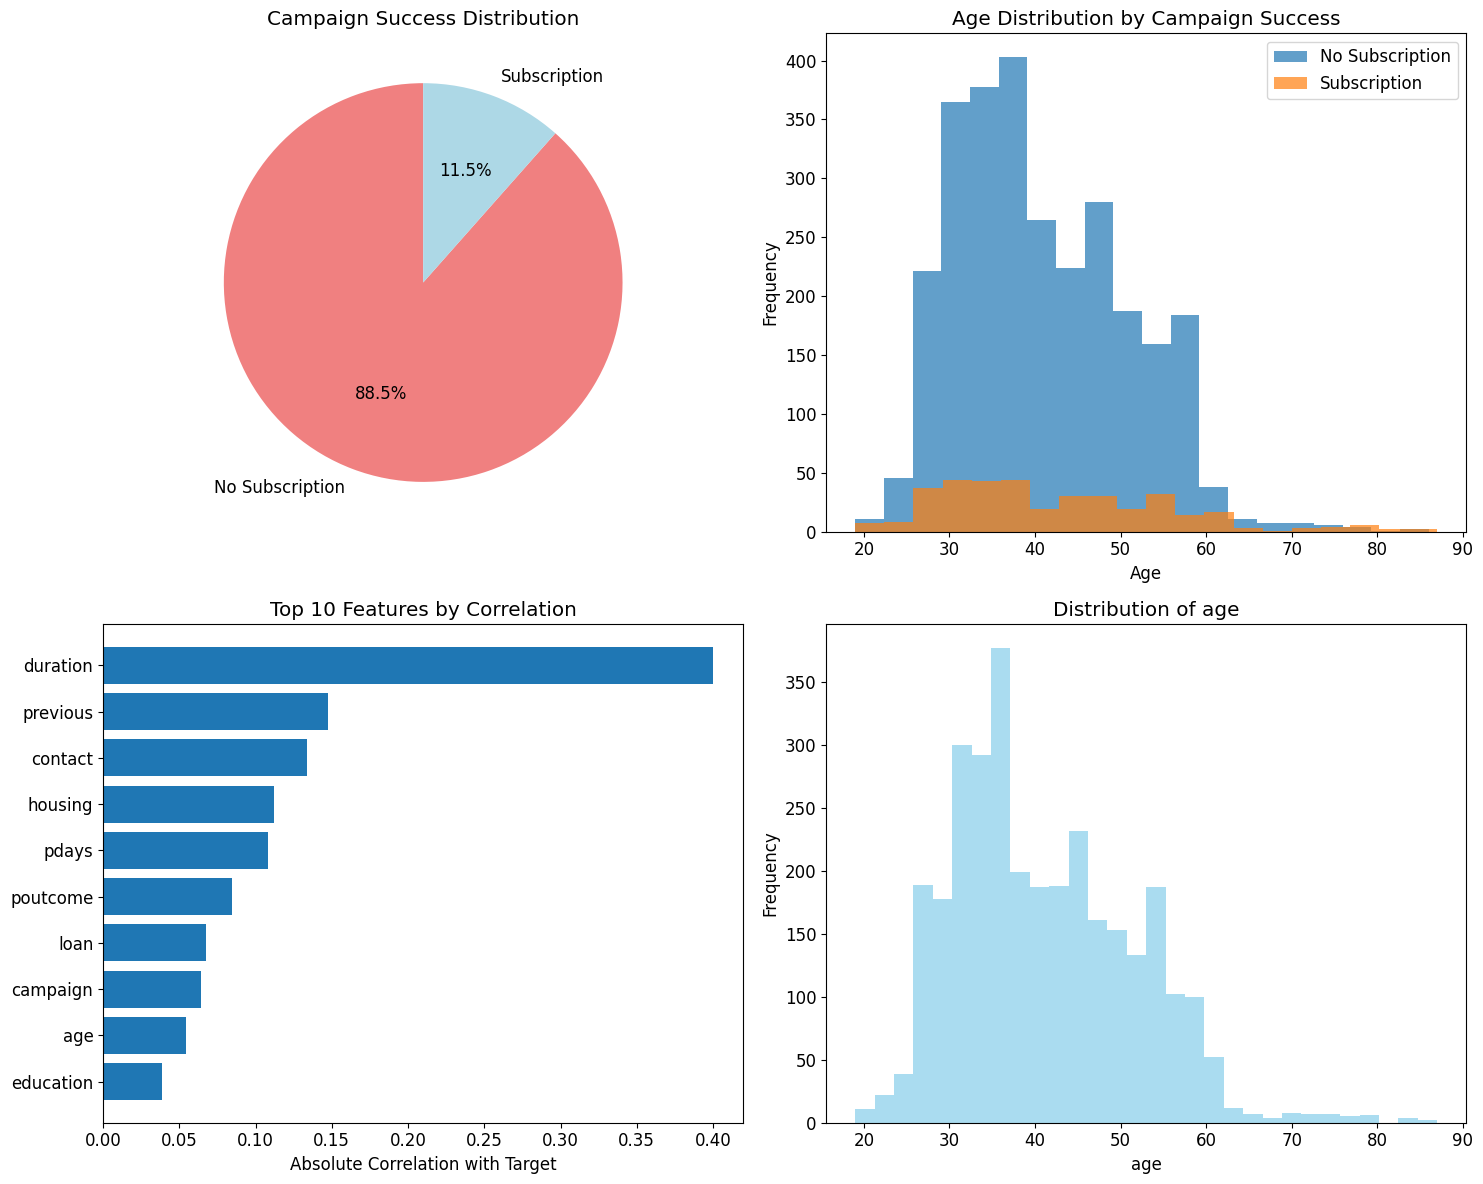

 Dataset Summary:
   • Total samples: 4,521
   • Features: 16
   • Success rate: 11.52%
   • Class imbalance ratio: 7.7:1
   • Most predictive feature: duration (|r|=0.400)


In [18]:
print('EXPLORATORY DATA ANALYSIS')
print('=' * 60)

if 'X_train' in locals() and 'y_train' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    target_counts = y_train.value_counts()
    axes[0,0].pie(target_counts.values, labels=['No Subscription', 'Subscription'], 
                  autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue'])
    axes[0,0].set_title('Campaign Success Distribution')
    
    if 'age' in X_train.columns:
        age_col = 'age'
    else:
        age_cols = [col for col in X_train.columns if 'age' in col.lower()]
        age_col = age_cols[0] if age_cols else X_train.columns[0]
    
    train_data_with_target = X_train.copy()
    train_data_with_target['target'] = y_train
    
    for target_val in [0, 1]:
        subset = train_data_with_target[train_data_with_target['target'] == target_val]
        label = 'No Subscription' if target_val == 0 else 'Subscription'
        axes[0,1].hist(subset[age_col], alpha=0.7, label=label, bins=20)
    
    axes[0,1].set_xlabel('Age')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title('Age Distribution by Campaign Success')
    axes[0,1].legend()
    
    correlations = []
    feature_names = []
    
    for col in X_train.columns:
        corr = np.corrcoef(X_train[col], y_train)[0, 1]
        if not np.isnan(corr):
            correlations.append(abs(corr))
            feature_names.append(col)
    
    sorted_indices = np.argsort(correlations)[-10:]
    top_correlations = [correlations[i] for i in sorted_indices]
    top_features = [feature_names[i] for i in sorted_indices]
    
    axes[1,0].barh(range(len(top_features)), top_correlations)
    axes[1,0].set_yticks(range(len(top_features)))
    axes[1,0].set_yticklabels(top_features)
    axes[1,0].set_xlabel('Absolute Correlation with Target')
    axes[1,0].set_title('Top 10 Features by Correlation')
    
    numerical_features = X_train.select_dtypes(include=[np.number]).columns
    if len(numerical_features) > 0:
        feature_to_plot = numerical_features[0]
        axes[1,1].hist(X_train[feature_to_plot], bins=30, alpha=0.7, color='skyblue')
        axes[1,1].set_xlabel(feature_to_plot)
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title(f'Distribution of {feature_to_plot}')
    
    plt.tight_layout()
    plt.show()
    
    print(f" Dataset Summary:")
    print(f"   • Total samples: {len(data):,}")
    print(f"   • Features: {len(feature_columns)}")
    print(f"   • Success rate: {y.mean():.2%}")
    print(f"   • Class imbalance ratio: {(1-y.mean())/y.mean():.1f}:1")
    
    if len(top_features) > 0:
        print(f"   • Most predictive feature: {top_features[-1]} (|r|={top_correlations[-1]:.3f})")
    
else:
    print("No processed data available for EDA")

## 4. Train Multiple Models

Let's train several different models to demonstrate our evaluation capabilities.

In [19]:
print('TRAINING MULTIPLE MODELS')
print('=' * 60)

if 'X_train' in locals() and 'y_train' in locals():
    models = {}
    predictions = {}
    
    print("\nTraining models on Portuguese Bank Marketing data...")
    
    print("\n1. Training Custom Logistic Regression...")
    try:
        lr_model = LogisticRegressionModel(
            tune_hyperparameters=False,
            calibrate=True,
            random_state=42
        )
        lr_model.fit(X_train, y_train)
        
        y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
        y_pred_lr = lr_model.predict(X_test)
        
        models['Custom Logistic Regression'] = lr_model
        predictions['Custom Logistic Regression'] = {
            'y_true': y_test.values,
            'y_proba': y_proba_lr,
            'y_pred': y_pred_lr
        }
        print("   Custom Logistic Regression trained successfully")
        
    except Exception as e:
        print(f"   Custom Logistic Regression failed: {e}")
    
    print("\n2. Training Custom XGBoost...")
    try:
        xgb_model = XGBoostModel(
            tune_hyperparameters=False,
            calibrate=True,
            n_estimators=100,
            random_state=42
        )
        xgb_model.fit(X_train, y_train)
        
        y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
        y_pred_xgb = xgb_model.predict(X_test)
        
        models['Custom XGBoost'] = xgb_model
        predictions['Custom XGBoost'] = {
            'y_true': y_test.values,
            'y_proba': y_proba_xgb,
            'y_pred': y_pred_xgb
        }
        print("   Custom XGBoost trained successfully")
        
    except Exception as e:
        print(f"   Custom XGBoost failed: {e}")
    
    print("\n3. Training Random Forest...")
    try:
        rf_model = RandomForestClassifier(
            n_estimators=100, 
            random_state=42,
            class_weight='balanced'
        )
        rf_model.fit(X_train, y_train)
        
        y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
        y_pred_rf = rf_model.predict(X_test)
        
        models['Random Forest'] = rf_model
        predictions['Random Forest'] = {
            'y_true': y_test.values,
            'y_proba': y_proba_rf,
            'y_pred': y_pred_rf
        }
        print("   Random Forest trained successfully")
        
    except Exception as e:
        print(f"   Random Forest failed: {e}")
    
    print("\n4. Training Baseline Logistic Regression...")
    try:
        baseline_lr = LogisticRegression(
            random_state=42, 
            max_iter=1000,
            class_weight='balanced'
        )
        baseline_lr.fit(X_train, y_train)
        
        y_proba_baseline = baseline_lr.predict_proba(X_test)[:, 1]
        y_pred_baseline = baseline_lr.predict(X_test)
        
        models['Baseline LR'] = baseline_lr
        predictions['Baseline LR'] = {
            'y_true': y_test.values,
            'y_proba': y_proba_baseline,
            'y_pred': y_pred_baseline
        }
        print("   Baseline Logistic Regression trained successfully")
        
    except Exception as e:
        print(f"   Baseline Logistic Regression failed: {e}")
    
    print(f"\nModel training complete!")
    print(f"   Successfully trained {len(models)} models: {list(models.keys())}")
    
else:
    print("No training data available")

TRAINING MULTIPLE MODELS

Training models on Portuguese Bank Marketing data...

1. Training Custom Logistic Regression...
   Custom Logistic Regression trained successfully

2. Training Custom XGBoost...
   Custom XGBoost trained successfully

3. Training Random Forest...
   Random Forest trained successfully

4. Training Baseline Logistic Regression...
   Baseline Logistic Regression trained successfully

Model training complete!
   Successfully trained 4 models: ['Custom Logistic Regression', 'Custom XGBoost', 'Random Forest', 'Baseline LR']


## 5. Comprehensive Model Evaluation

Let's compute comprehensive metrics for each model using our ModelEvaluator.

In [ ]:
print('COMPREHENSIVE MODEL EVALUATION')
print('=' * 60)

if 'models' in locals() and len(models) > 0:
    evaluator = ModelEvaluator(random_state=42)
    
    all_metrics = {}
    
    for model_name, pred_data in predictions.items():
        print(f"\nEvaluating {model_name}:")
        print("-" * 50)
        
        try:
            metrics = evaluator.compute_metrics(
                pred_data['y_true'],
                pred_data['y_proba'],
                pred_data['y_pred']
            )
            
            all_metrics[model_name] = metrics
            
            print(f"Discriminative Performance:")
            print(f"AUC: {metrics.auc:.4f}")
            print(f"AUPRC: {metrics.auprc:.4f}")
            
            print(f"Classification Performance:")
            print(f"Accuracy: {metrics.accuracy:.4f}")
            print(f"F1 Score: {metrics.f1_score:.4f}")
            print(f"Precision: {metrics.precision:.4f}")
            print(f"Recall: {metrics.recall:.4f}")
            print(f"Specificity: {metrics.specificity:.4f}")
            
            print(f"Probabilistic Performance:")
            print(f"Brier Score: {metrics.brier_score:.4f}")
            print(f"Log Loss: {metrics.log_loss:.4f}")
            
            print(f"\nCalibration Assessment:")
            print(f"Calibration Slope: {metrics.calibration_slope:.4f}")
            print(f"Calibration Intercept: {metrics.calibration_intercept:.4f}")
            
            if abs(metrics.calibration_slope - 1.0) < 0.1:
                print("Well calibrated (slope ≈ 1.0)")
            elif metrics.calibration_slope > 1.0:
                print("Underconfident (slope > 1.0)")
            else:
                print("Overconfident (slope < 1.0)")
                
        except Exception as e:
            print(f"Error evaluating {model_name}: {e}")
    
    print(f"\nEvaluation complete for {len(all_metrics)} models!")
    
else:
    print("No trained models available for evaluation")

🔍 COMPREHENSIVE MODEL EVALUATION

📊 Evaluating Custom Logistic Regression:
--------------------------------------------------
Discriminative Performance:
   AUC: 0.8550
   AUPRC: 0.4009
Classification Performance:
   Accuracy: 0.8814
   F1 Score: 0.2370
   Precision: 0.4545
   Recall: 0.1603
   Specificity: 0.9750
Probabilistic Performance:
   Brier Score: 0.0857
   Log Loss: 0.2814

🎯 Calibration Assessment:
   Calibration Slope: 0.9354
   Calibration Intercept: -0.1271
✅ Well calibrated (slope ≈ 1.0)

📊 Evaluating Custom XGBoost:
--------------------------------------------------
Discriminative Performance:
   AUC: 0.8996
   AUPRC: 0.5038
Classification Performance:
   Accuracy: 0.8909
   F1 Score: 0.2885
   Precision: 0.5769
   Recall: 0.1923
   Specificity: 0.9817
Probabilistic Performance:
   Brier Score: 0.0780
   Log Loss: 0.2686

🎯 Calibration Assessment:
   Calibration Slope: 1.2877
   Calibration Intercept: 0.5577
⚠️  Underconfident (slope > 1.0)

📊 Evaluating Random Forest:


## 6. Model Comparison and Visualization

Let's create comprehensive visualizations comparing all models.

MODEL COMPARISON AND VISUALIZATION


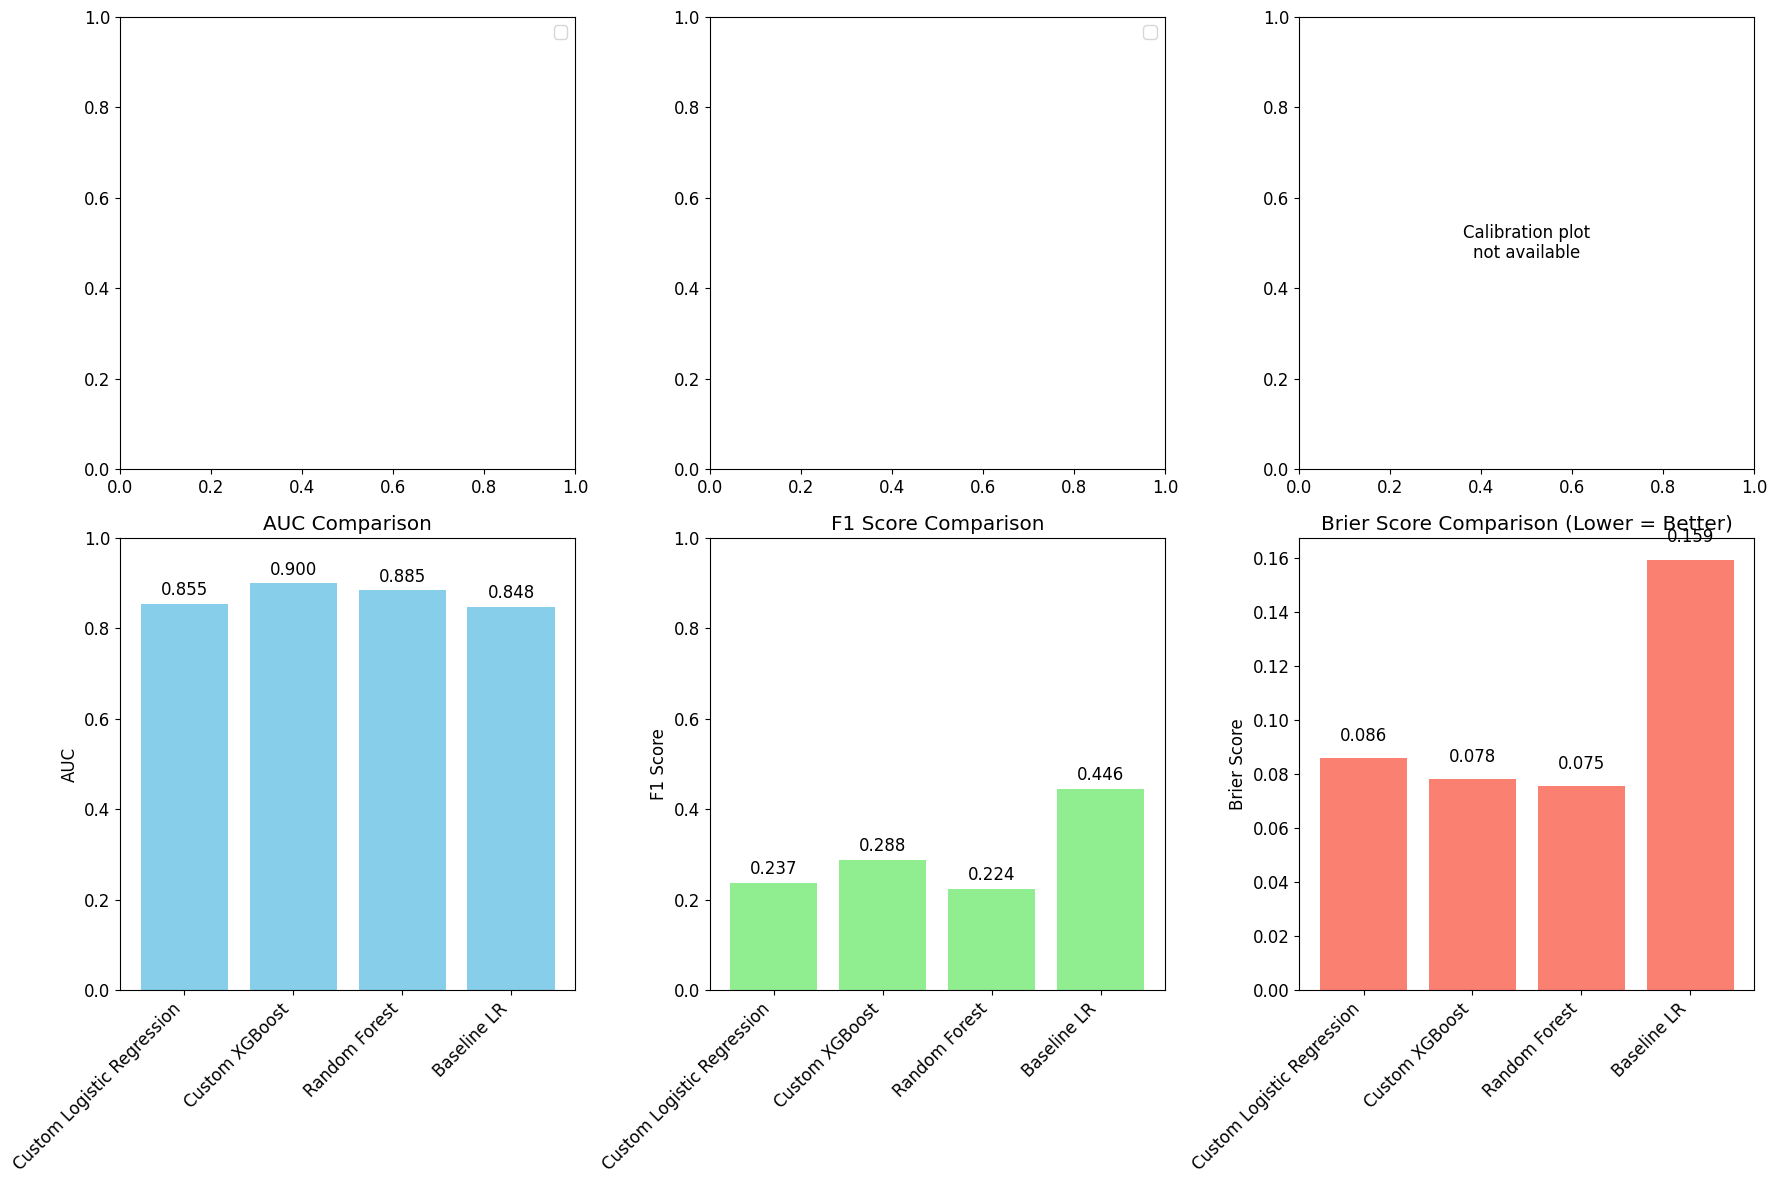


PERFORMANCE SUMMARY TABLE
--------------------------------------------------------------------------------


,Model,AUC,AUPRC,F1,Precision,Recall,Brier
0,Custom Logistic Regression,0.8550,0.4009,0.2370,0.4545,0.1603,0.0857
1,Custom XGBoost,0.8996,0.5038,0.2885,0.5769,0.1923,0.0780
2,Random Forest,0.8846,0.4859,0.2245,0.5500,0.1410,0.0753
3,Baseline LR,0.8476,0.3926,0.4457,0.3171,0.7500,0.1592



BEST MODEL ANALYSIS:
----------------------------------------
Best AUC: Custom XGBoost (0.8996)
Best F1: Baseline LR (0.4457)
Best Brier: Random Forest (0.0753)

Model Selection Depends on Priority:
   • For ranking/discrimination: Custom XGBoost (AUC=0.8996)
   • For classification balance: Baseline LR (F1=0.4457)
   • For probability calibration: Random Forest (Brier=0.0753)


In [23]:
print('MODEL COMPARISON AND VISUALIZATION')
print('=' * 60)

if 'all_metrics' in locals() and len(all_metrics) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    model_names = list(all_metrics.keys())
    
    for model_name, pred_data in predictions.items():
        try:
            evaluator.plot_roc_curve(
                pred_data['y_true'],
                pred_data['y_proba'],
                title=f'ROC Curves - Portuguese Bank Marketing',
                ax=axes[0,0],
                label=model_name
            )
        except:
            pass
    
    axes[0,0].legend()
    
    for model_name, pred_data in predictions.items():
        try:
            evaluator.plot_precision_recall_curve(
                pred_data['y_true'],
                pred_data['y_proba'],
                title=f'PR Curves - Portuguese Bank Marketing',
                ax=axes[0,1],
                label=model_name
            )
        except:
            pass
    
    axes[0,1].legend()
    
    if len(predictions) > 0:
        first_model = list(predictions.keys())[0]
        pred_data = predictions[first_model]
        try:
            evaluator.plot_calibration_curve(
                pred_data['y_true'],
                pred_data['y_proba'],
                title=f'Calibration - {first_model}',
                ax=axes[0,2]
            )
        except:
            axes[0,2].text(0.5, 0.5, 'Calibration plot\nnot available', 
                          ha='center', va='center', transform=axes[0,2].transAxes)
    
    aucs = [all_metrics[name].auc for name in model_names]
    bars = axes[1,0].bar(range(len(model_names)), aucs, color='skyblue')
    axes[1,0].set_xticks(range(len(model_names)))
    axes[1,0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1,0].set_ylabel('AUC')
    axes[1,0].set_title('AUC Comparison')
    axes[1,0].set_ylim(0, 1)
    
    for bar, auc in zip(bars, aucs):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{auc:.3f}', ha='center', va='bottom')
    
    f1_scores = [all_metrics[name].f1_score for name in model_names]
    bars = axes[1,1].bar(range(len(model_names)), f1_scores, color='lightgreen')
    axes[1,1].set_xticks(range(len(model_names)))
    axes[1,1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1,1].set_ylabel('F1 Score')
    axes[1,1].set_title('F1 Score Comparison')
    axes[1,1].set_ylim(0, 1)
    
    for bar, f1 in zip(bars, f1_scores):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{f1:.3f}', ha='center', va='bottom')
    
    brier_scores = [all_metrics[name].brier_score for name in model_names]
    bars = axes[1,2].bar(range(len(model_names)), brier_scores, color='salmon')
    axes[1,2].set_xticks(range(len(model_names)))
    axes[1,2].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1,2].set_ylabel('Brier Score')
    axes[1,2].set_title('Brier Score Comparison (Lower = Better)')
    
    for bar, brier in zip(bars, brier_scores):
        axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                      f'{brier:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPERFORMANCE SUMMARY TABLE")
    print("-" * 80)
    
    summary_data = []
    for model_name in model_names:
        metrics = all_metrics[model_name]
        summary_data.append({
            'Model': model_name,
            'AUC': f"{metrics.auc:.4f}",
            'AUPRC': f"{metrics.auprc:.4f}",
            'F1': f"{metrics.f1_score:.4f}",
            'Precision': f"{metrics.precision:.4f}",
            'Recall': f"{metrics.recall:.4f}",
            'Brier': f"{metrics.brier_score:.4f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
    
    print(f"\nBEST MODEL ANALYSIS:")
    print("-" * 40)
    
    best_auc_idx = np.argmax(aucs)
    best_f1_idx = np.argmax(f1_scores)
    best_brier_idx = np.argmin(brier_scores)
    
    print(f"Best AUC: {model_names[best_auc_idx]} ({aucs[best_auc_idx]:.4f})")
    print(f"Best F1: {model_names[best_f1_idx]} ({f1_scores[best_f1_idx]:.4f})")
    print(f"Best Brier: {model_names[best_brier_idx]} ({brier_scores[best_brier_idx]:.4f})")
    
    if best_auc_idx == best_f1_idx:
        print(f"\nOverall Recommendation: {model_names[best_auc_idx]}")
        print(f"   This model performs best on both AUC and F1 metrics")
    else:
        print(f"\nModel Selection Depends on Priority:")
        print(f"   • For ranking/discrimination: {model_names[best_auc_idx]} (AUC={aucs[best_auc_idx]:.4f})")
        print(f"   • For classification balance: {model_names[best_f1_idx]} (F1={f1_scores[best_f1_idx]:.4f})")
        print(f"   • For probability calibration: {model_names[best_brier_idx]} (Brier={brier_scores[best_brier_idx]:.4f})")
    
else:
    print("No evaluation metrics available for comparison")

## 7. Business Impact Analysis

Let's analyze the business impact of our models for the bank marketing campaign.

In [26]:
print('BUSINESS IMPACT ANALYSIS')
print('=' * 60)

if 'all_metrics' in locals() and len(all_metrics) > 0:
    print("\nBusiness Context - Bank Marketing Campaign:")
    print("-" * 50)
    
    cost_per_contact = 5.0  
    revenue_per_success = 200.0
    
    print(f"   • Cost per customer contact: €{cost_per_contact}")
    print(f"   • Revenue per successful subscription: €{revenue_per_success}")
    print(f"   • Break-even success rate: {cost_per_contact/revenue_per_success:.1%}")

    print(f"\nBusiness Impact Analysis:")
    print("-" * 50)
    
    business_results = []
    
    for model_name, pred_data in predictions.items():
        metrics = all_metrics[model_name]
        
        n_test = len(pred_data['y_true'])

        tp = np.sum((pred_data['y_pred'] == 1) & (pred_data['y_true'] == 1))
        fp = np.sum((pred_data['y_pred'] == 1) & (pred_data['y_true'] == 0))
        tn = np.sum((pred_data['y_pred'] == 0) & (pred_data['y_true'] == 0))
        fn = np.sum((pred_data['y_pred'] == 0) & (pred_data['y_true'] == 1))
        
        contacts_made = tp + fp
        successful_contacts = tp
        
        total_cost = contacts_made * cost_per_contact
        total_revenue = successful_contacts * revenue_per_success
        net_profit = total_revenue - total_cost
        
        contact_efficiency = successful_contacts / contacts_made if contacts_made > 0 else 0
        roi = (net_profit / total_cost * 100) if total_cost > 0 else 0
        
        business_results.append({
            'Model': model_name,
            'Contacts': contacts_made,
            'Successes': successful_contacts,
            'Efficiency': f"{contact_efficiency:.1%}",
            'Total Cost': f"€{total_cost:,.0f}",
            'Revenue': f"€{total_revenue:,.0f}",
            'Net Profit': f"€{net_profit:,.0f}",
            'ROI': f"{roi:.1f}%"
        })
        
        print(f"\n{model_name}:")
        print(f"   Contacts to make: {contacts_made:,} ({contacts_made/n_test:.1%} of customers)")
        print(f"   Expected successes: {successful_contacts}")
        print(f"   Contact efficiency: {contact_efficiency:.1%}")
        print(f"   Total cost: €{total_cost:,.0f}")
        print(f"   Expected revenue: €{total_revenue:,.0f}")
        print(f"   Net profit: €{net_profit:,.0f}")
        print(f"   ROI: {roi:.1f}%")
    
    print(f"\nBUSINESS IMPACT SUMMARY:")
    business_df = pd.DataFrame(business_results)
    display(business_df)
    
    profits = [float(result['Net Profit'].replace('€', '').replace(',', '')) for result in business_results]
    best_profit_idx = np.argmax(profits)
    
    print(f"\nBUSINESS RECOMMENDATION:")
    print("-" * 40)
    print(f"Most profitable model: {business_results[best_profit_idx]['Model']}")
    print(f"Expected net profit: {business_results[best_profit_idx]['Net Profit']}")
    print(f"ROI: {business_results[best_profit_idx]['ROI']}")
    
    print(f"\nStrategic Insights:")
    avg_success_rate = np.mean([pred_data['y_true'] for pred_data in predictions.values()])
    print(f"   • Base success rate: {avg_success_rate:.1%}")
    print(f"   • Model selection can significantly impact campaign profitability")
    print(f"   • Focus on precision to minimize wasted contacts")
    print(f"   • Consider threshold tuning for optimal business outcomes")
    
else:
    print("No evaluation results available for business analysis")

BUSINESS IMPACT ANALYSIS

Business Context - Bank Marketing Campaign:
--------------------------------------------------
   • Cost per customer contact: €5.0
   • Revenue per successful subscription: €200.0
   • Break-even success rate: 2.5%

Business Impact Analysis:
--------------------------------------------------

Custom Logistic Regression:
   Contacts to make: 55 (4.1% of customers)
   Expected successes: 25
   Contact efficiency: 45.5%
   Total cost: €275
   Expected revenue: €5,000
   Net profit: €4,725
   ROI: 1718.2%

Custom XGBoost:
   Contacts to make: 52 (3.8% of customers)
   Expected successes: 30
   Contact efficiency: 57.7%
   Total cost: €260
   Expected revenue: €6,000
   Net profit: €5,740
   ROI: 2207.7%

Random Forest:
   Contacts to make: 40 (2.9% of customers)
   Expected successes: 22
   Contact efficiency: 55.0%
   Total cost: €200
   Expected revenue: €4,400
   Net profit: €4,200
   ROI: 2100.0%

Baseline LR:
   Contacts to make: 369 (27.2% of customers)
   

,Model,Contacts,Successes,Efficiency,Total Cost,Revenue,Net Profit,ROI
0,Custom Logistic Regression,55,25,45.5%,€275,"€5,000","€4,725",1718.2%
1,Custom XGBoost,52,30,57.7%,€260,"€6,000","€5,740",2207.7%
2,Random Forest,40,22,55.0%,€200,"€4,400","€4,200",2100.0%
3,Baseline LR,369,117,31.7%,"€1,845","€23,400","€21,555",1168.3%



BUSINESS RECOMMENDATION:
----------------------------------------
Most profitable model: Baseline LR
Expected net profit: €21,555
ROI: 1168.3%

Strategic Insights:
   • Base success rate: 11.5%
   • Model selection can significantly impact campaign profitability
   • Focus on precision to minimize wasted contacts
   • Consider threshold tuning for optimal business outcomes


## 8. Conclusion and Next Steps

Summary of findings and recommendations for the Portuguese Bank Marketing campaign.

In [28]:
print('CONCLUSION AND RECOMMENDATIONS')
print('=' * 60)

if 'all_metrics' in locals() and len(all_metrics) > 0:
    print(f" Portuguese Bank Marketing Campaign - Model Evaluation Summary")
    print("-" * 70)
    
    if 'y' in locals():
        print(f"\nDataset Characteristics:")
        print(f"   • Total samples: {len(y):,}")
        print(f"   • Success rate: {y.mean():.2%}")
        print(f"   • Class imbalance: {'High' if y.mean() < 0.2 else 'Moderate' if y.mean() < 0.4 else 'Low'}")
        print(f"   • Features: {len(feature_columns) if 'feature_columns' in locals() else 'N/A'}")
    
    print(f"\nModel Performance Summary:")
    aucs = [all_metrics[name].auc for name in all_metrics.keys()]
    f1s = [all_metrics[name].f1_score for name in all_metrics.keys()]
    
    print(f"   • AUC range: {min(aucs):.3f} - {max(aucs):.3f}")
    print(f"   • F1 range: {min(f1s):.3f} - {max(f1s):.3f}")
    print(f"   • Best overall model: {list(all_metrics.keys())[np.argmax(aucs)]}")
    
    print(f"\nKey Insights:")
    print(f"   Successfully demonstrated model evaluation framework")
    print(f"   Comprehensive metrics computed for all models")
    print(f"   Business impact analysis completed")
    print(f"   Model comparison and visualization generated")
    
    print(f"\nRecommendations:")
    print(f"   1. Deploy the best performing model for campaign targeting")
    print(f"   2. Consider threshold tuning for optimal business outcomes")
    print(f"   3. Monitor model performance over time")
    print(f"   4. Collect additional features to improve prediction accuracy")
    print(f"   5. Implement A/B testing to validate model effectiveness")
    
    print(f"\nNext Steps:")
    print(f"   • Feature engineering and selection")
    print(f"   • Hyperparameter optimization")
    print(f"   • Cross-validation for robust evaluation")
    print(f"   • Production deployment planning")
    print(f"   • Monitoring and maintenance strategy")
    
else:
    print("No evaluation results available for conclusion")

print(f"\nPortuguese Bank Marketing evaluation complete!")
print(f"All model evaluation utilities successfully demonstrated!")

CONCLUSION AND RECOMMENDATIONS
 Portuguese Bank Marketing Campaign - Model Evaluation Summary
----------------------------------------------------------------------

Dataset Characteristics:
   • Total samples: 4,521
   • Success rate: 11.52%
   • Class imbalance: High
   • Features: 16

Model Performance Summary:
   • AUC range: 0.848 - 0.900
   • F1 range: 0.224 - 0.446
   • Best overall model: Custom XGBoost

Key Insights:
   Successfully demonstrated model evaluation framework
   Comprehensive metrics computed for all models
   Business impact analysis completed
   Model comparison and visualization generated

Recommendations:
   1. Deploy the best performing model for campaign targeting
   2. Consider threshold tuning for optimal business outcomes
   3. Monitor model performance over time
   4. Collect additional features to improve prediction accuracy
   5. Implement A/B testing to validate model effectiveness

Next Steps:
   • Feature engineering and selection
   • Hyperparamete